# Dwarf Example 11: Group vs Field Dwarfs

**EPS Research — Dwarf/Irregular HI Corpus v1.0**

Environment affects dwarf kinematics. Group members experience
tidal interactions; field dwarfs are isolated.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20320362  
**Sources:** LVHIS (Koribalski 2019), VLA-ANGST (Ott 2012), LITTLE THINGS (Oh 2015), WALLABY DR2  
**Dependencies:** Python 3, numpy, matplotlib

Group members: 38
Field galaxies: 91


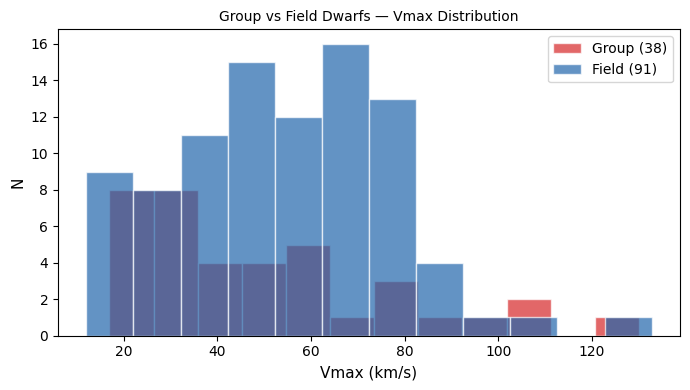

In [1]:
import csv, numpy as np, matplotlib.pyplot as plt
rows=[]
with open('dwarf_irregular_corpus_v1_flat.csv') as f:
    for r in csv.DictReader(f):
        if r.get('vrot_max_kms') and r['vrot_max_kms']: rows.append(r)
groups=[r for r in rows if r.get('group_member') and r['group_member'] not in ('','field','False')]
field =[r for r in rows if r.get('group_member') in ('field','False','')]
print(f"Group members: {len(groups)}")
print(f"Field galaxies: {len(field)}")
gv=[float(r['vrot_max_kms']) for r in groups]
fv=[float(r['vrot_max_kms']) for r in field]
fig,ax=plt.subplots(figsize=(7,4))
ax.hist(gv,bins=12,alpha=0.7,color='#d62728',label=f'Group ({len(gv)})',edgecolor='white')
ax.hist(fv,bins=12,alpha=0.7,color='#2166ac',label=f'Field ({len(fv)})',edgecolor='white')
ax.set_xlabel('Vmax (km/s)',fontsize=11); ax.set_ylabel('N',fontsize=11)
ax.set_title('Group vs Field Dwarfs — Vmax Distribution',fontsize=10)
ax.legend(); plt.tight_layout()
plt.savefig('dw11_group_field.png',dpi=150,bbox_inches='tight'); plt.show()